# BPCRR-INLA Merged Output Visualization

This notebook validates and visualizes merged BPCRR-INLA rank-selection outputs against shard-level outputs.

## Simple Comparison Notebook

Goal:
- One figure averaged over selected target islands (default 11)
- One grid with one panel per selected target island
- BPCRR merged results + optional ridge overlay from another output folder

In [28]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = next((p for p in root_candidates if (p / "outputs").exists()), cwd)

# Main run (used for all standard BPCRR curves and baselines).
BPCRR_MAIN_DIR = PROJECT_ROOT / "outputs" / "bpcrr_inla_2.0"
# Optional extra run: only PEV-based BPCRR curves should be taken from here.
BPCRR_PEV_DIR = PROJECT_ROOT / "outputs" / "bpcrr_inla_pev"

RIDGE_PCA_DIR = PROJECT_ROOT / "outputs" / "pca_source_rank_weight_test4"   # set to None to disable
RIDGE_AVGGRM_DIR = PROJECT_ROOT / "outputs" / "avggrm_rank_weight_all" / "body_mass"  # set to None to disable
RIDGE_PEV_DIR = PROJECT_ROOT / "outputs" / "ridge_pev"  # set to None to disable
AVGGRM_DIVERSITY_DIR = PROJECT_ROOT / "outputs" / "avggrm_diversity_greedy"  # set to None to disable

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BPCRR_MAIN_DIR exists:", BPCRR_MAIN_DIR.exists())
print("BPCRR_PEV_DIR exists:", BPCRR_PEV_DIR.exists() if BPCRR_PEV_DIR is not None else False)
print("RIDGE_PCA_DIR exists:", RIDGE_PCA_DIR.exists() if RIDGE_PCA_DIR is not None else False)
print("RIDGE_AVGGRM_DIR exists:", RIDGE_AVGGRM_DIR.exists() if RIDGE_AVGGRM_DIR is not None else False)
print("RIDGE_PEV_DIR exists:", RIDGE_PEV_DIR.exists() if RIDGE_PEV_DIR is not None else False)
print("AVGGRM_DIVERSITY_DIR exists:", AVGGRM_DIVERSITY_DIR.exists() if AVGGRM_DIVERSITY_DIR is not None else False)

TMC_INDIVIDUAL_SOURCES = [
    {
        "source": "grouped_10",
        "model": "ridge_tmc_individual",
        "dir": PROJECT_ROOT / "outputs" / "tmc_shapley_individuals_grouped",
    },
]
# Backwards-compatible convenience variable for older cells.
TMC_INDIVIDUAL_DIR = TMC_INDIVIDUAL_SOURCES[0]["dir"]
for src in TMC_INDIVIDUAL_SOURCES:
    print(f"TMC source {src['source']} exists:", src["dir"].exists())


PROJECT_ROOT: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
BPCRR_MAIN_DIR exists: True
BPCRR_PEV_DIR exists: True
RIDGE_PCA_DIR exists: True
RIDGE_AVGGRM_DIR exists: True
RIDGE_PEV_DIR exists: True
AVGGRM_DIVERSITY_DIR exists: True
TMC source grouped_10 exists: True


## Load BPCRR and Optional Ridge

In [29]:
def _find_csv(base_dir: Path, filename: str) -> Path | None:
    candidates = [
        base_dir / filename,
        *sorted(base_dir.glob(f"*/{filename}")),
        *sorted(base_dir.glob(f"*/*/{filename}")),
    ]
    return next((p for p in candidates if p.exists()), None)


def _load_and_standardize(path: Path, model_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    rename_map = {}
    if "selection_method" in df.columns and "method" not in df.columns:
        rename_map["selection_method"] = "method"
    if "n_train_size" in df.columns and "n_individuals" not in df.columns:
        rename_map["n_train_size"] = "n_individuals"
    if rename_map:
        df = df.rename(columns=rename_map)

    required = ["target_island", "n_individuals", "corr_eval"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{model_name}: missing required columns {missing} in {path}")

    if "method" not in df.columns:
        df["method"] = model_name

    if "lambda_label" in df.columns and "method" in df.columns:
        is_diversity = df["method"].astype(str).str.contains("avggrm_diversity_greedy", case=False, na=False)
        has_lambda = (
            df["lambda_label"].notna()
            & ~df["lambda_label"].astype(str).str.lower().isin(["none", "nan"])
        )
        if "lambda_div" in df.columns:
            lambda_text = pd.to_numeric(df["lambda_div"], errors="coerce").map(
                lambda x: f"lambda={x:g}" if pd.notna(x) else ""
            )
        else:
            lambda_text = df["lambda_label"].astype(str).str.replace("lambda_", "lambda=", regex=False)
        mask = is_diversity & has_lambda
        df.loc[mask, "method"] = df.loc[mask, "method"].astype(str) + " (" + lambda_text.loc[mask] + ")"

    df["target_island"] = pd.to_numeric(df["target_island"], errors="coerce")
    df["n_individuals"] = pd.to_numeric(df["n_individuals"], errors="coerce")
    df["corr_eval"] = pd.to_numeric(df["corr_eval"], errors="coerce")
    df = df.dropna(subset=["target_island", "n_individuals", "corr_eval"]).copy()
    df["target_island"] = df["target_island"].astype(int)
    df["n_individuals"] = df["n_individuals"].astype(int)
    if model_name == "avggrm_diversity" and "model_type" in df.columns:
        model_map = {
            "ridge": "ridge_avggrm_diversity",
            "bpcrr": "bpcrr_avggrm_diversity",
        }
        df["model"] = (
            df["model_type"].astype(str).str.lower().map(model_map).fillna("avggrm_diversity")
        )
    else:
        df["model"] = model_name
    return df


def _keep_pev_methods(df: pd.DataFrame) -> pd.DataFrame:
    # Only keep explicit PEV curves from the supplemental BPCRR run.
    mask = df["method"].astype(str).str.contains("pev", case=False, na=False)
    return df[mask].copy()


bpcrr_main_path = _find_csv(BPCRR_MAIN_DIR, "bpcrr_inla_rank_select_results.csv")
if bpcrr_main_path is None:
    raise FileNotFoundError("Could not find bpcrr_inla_rank_select_results.csv in BPCRR_MAIN_DIR")
bpcrr_main = _load_and_standardize(bpcrr_main_path, "bpcrr")
print("Loaded BPCRR main:", bpcrr_main_path, bpcrr_main.shape)

parts = [bpcrr_main]

bpcrr_pev = pd.DataFrame()
bpcrr_pev_path = None
if BPCRR_PEV_DIR is not None:
    bpcrr_pev_path = _find_csv(BPCRR_PEV_DIR, "bpcrr_inla_rank_select_results.csv")
    if bpcrr_pev_path is not None:
        bpcrr_pev_all = _load_and_standardize(bpcrr_pev_path, "bpcrr")
        bpcrr_pev = _keep_pev_methods(bpcrr_pev_all)
        if not bpcrr_pev.empty:
            parts.append(bpcrr_pev)
            print("Loaded BPCRR PEV curves:", bpcrr_pev_path, bpcrr_pev.shape)
        else:
            print("No PEV-labeled methods found in:", bpcrr_pev_path)
    else:
        print("BPCRR PEV source file not found under", BPCRR_PEV_DIR)

bpcrr_selected_path = _find_csv(BPCRR_PEV_DIR, "bpcrr_inla_ranked_selected_individuals.csv") if BPCRR_PEV_DIR is not None else None
bpcrr_selected = pd.DataFrame()
if bpcrr_selected_path is not None:
    bpcrr_selected = pd.read_csv(bpcrr_selected_path)
    print("Loaded BPCRR selected individuals:", bpcrr_selected_path, bpcrr_selected.shape)
    cols = [c for c in ["trait", "target_island", "method", "n_train_size", "ringnr"] if c in bpcrr_selected.columns]
    if cols:
        display(bpcrr_selected[cols].head(10))
    else:
        display(bpcrr_selected.head(10))

    summary_cols = [c for c in ["trait", "target_island", "method", "n_train_size"] if c in bpcrr_selected.columns]
    if summary_cols:
        bpcrr_selected_summary = (
            bpcrr_selected.groupby(summary_cols, dropna=False, as_index=False)
            .size()
            .rename(columns={"size": "n_selected_rows"})
            .sort_values(summary_cols)
        )
        print("BPCRR selected summary (first 20 rows):")
        display(bpcrr_selected_summary.head(20))
else:
    print("BPCRR selected individuals file not found under", BPCRR_PEV_DIR)

ridge_pca = pd.DataFrame()
if RIDGE_PCA_DIR is not None:
    ridge_pca_path = _find_csv(RIDGE_PCA_DIR, "pca_source_rank_weight_results.csv")
    if ridge_pca_path is not None:
        ridge_pca = _load_and_standardize(ridge_pca_path, "ridge_pca")
        parts.append(ridge_pca)
        print("Loaded ridge PCA:", ridge_pca_path, ridge_pca.shape)
    else:
        print("Ridge PCA results file not found under", RIDGE_PCA_DIR)

ridge_avggrm = pd.DataFrame()
if RIDGE_AVGGRM_DIR is not None:
    ridge_avggrm_path = _find_csv(RIDGE_AVGGRM_DIR, "avggrm_rank_weight_results.csv")
    if ridge_avggrm_path is not None:
        ridge_avggrm = _load_and_standardize(ridge_avggrm_path, "ridge_avggrm")
        parts.append(ridge_avggrm)
        print("Loaded ridge avgGRM:", ridge_avggrm_path, ridge_avggrm.shape)
    else:
        print("Ridge avgGRM results file not found under", RIDGE_AVGGRM_DIR)

ridge_pev = pd.DataFrame()
if RIDGE_PEV_DIR is not None:
    ridge_pev_path = _find_csv(RIDGE_PEV_DIR, "pevmean_ga_results.csv")
    if ridge_pev_path is not None:
        ridge_pev = _load_and_standardize(ridge_pev_path, "ridge_pev")
        parts.append(ridge_pev)
        print("Loaded ridge PEV:", ridge_pev_path, ridge_pev.shape)
    else:
        print("Ridge PEV results file not found under", RIDGE_PEV_DIR)

avggrm_diversity = pd.DataFrame()
if AVGGRM_DIVERSITY_DIR is not None:
    avggrm_diversity_path = _find_csv(AVGGRM_DIVERSITY_DIR, "avggrm_diversity_greedy_results.csv")
    if avggrm_diversity_path is not None:
        avggrm_diversity = _load_and_standardize(avggrm_diversity_path, "avggrm_diversity")
        parts.append(avggrm_diversity)
        print("Loaded avgGRM diversity greedy:", avggrm_diversity_path, avggrm_diversity.shape)
    else:
        print("AvgGRM diversity greedy results file not found under", AVGGRM_DIVERSITY_DIR)

tmc_individual = pd.DataFrame()
tmc_individual_shap_stats = pd.DataFrame()
tmc_eval_stats = pd.DataFrame()


def _suffix_tmc_method(method: object, source_name: str) -> str:
    method = str(method)
    if method == "full_source_unweighted":
        return method
    return f"{method} ({source_name})"


def _load_tmc_source(source_cfg: dict) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    source_name = str(source_cfg["source"])
    model_name = str(source_cfg["model"])
    base_dir = Path(source_cfg["dir"])

    topk_df = pd.DataFrame()
    shap_df = pd.DataFrame()
    eval_df = pd.DataFrame()

    if not base_dir.exists():
        print(f"TMC source {source_name} not found:", base_dir)
        return topk_df, shap_df, eval_df

    topk_path = base_dir / "tmc_individual_topk_results.csv"
    if topk_path.exists():
        topk_df = _load_and_standardize(topk_path, model_name)
        topk_df["tmc_source"] = source_name
        topk_df["method"] = topk_df["method"].map(lambda m: _suffix_tmc_method(m, source_name))
        print(f"Loaded TMC individual top-k results ({source_name}):", topk_path, topk_df.shape)
    else:
        print(f"TMC individual top-k results not found for {source_name} at", topk_path)

    shap_path = base_dir / "tmc_individual_shap_per_source_island.csv"
    if shap_path.exists():
        shap_df = pd.read_csv(shap_path)
        shap_df["tmc_source"] = source_name
        shap_df["model"] = model_name
        print(f"Loaded TMC Shapley source-island stats ({source_name}):", shap_path, shap_df.shape)

    rows = []
    for summary_path in sorted(base_dir.glob("island_*/repeat_*/tmc_individual_summary_target_*.json")):
        with open(summary_path, "r") as f:
            payload = json.load(f)
        stats = payload.get("stats", {})
        n_players = int(stats.get("n_players", 0) or 0)
        n_perms = int(stats.get("n_permutations", 0) or 0)
        n_utility_evals = int(stats.get("n_utility_evals", 0) or 0)
        group_size = int(stats.get("group_size", 1) or 1)
        prefix_eval_count = max(0, n_utility_evals - 1)  # subtract V_full
        if "eval_counts_mean" in stats:
            evals_per_individual_mean = float(stats["eval_counts_mean"])
            evals_per_individual_std = float(stats.get("eval_counts_std", np.nan))
            evals_per_individual_min = float(stats.get("eval_counts_min", np.nan))
            evals_per_individual_max = float(stats.get("eval_counts_max", np.nan))
        elif n_players > 0:
            # Older non-grouped outputs did not save per-individual counts. With random
            # permutations, the mean count is implied by total evaluated prefix length.
            evals_per_individual_mean = prefix_eval_count * group_size / n_players
            evals_per_individual_std = np.nan
            evals_per_individual_min = np.nan
            evals_per_individual_max = np.nan
        else:
            evals_per_individual_mean = np.nan
            evals_per_individual_std = np.nan
            evals_per_individual_min = np.nan
            evals_per_individual_max = np.nan

        rows.append({
            "tmc_source": source_name,
            "model": model_name,
            "target_island": int(payload.get("target_island", -1)),
            "target_island_name": payload.get("target_island_name", ""),
            "repeat": int(payload.get("repeat", -1)),
            "split_seed": int(payload.get("split_seed", -1)),
            "n_players": n_players,
            "n_permutations": n_perms,
            "n_truncated": int(stats.get("n_truncated", 0) or 0),
            "n_utility_evals": n_utility_evals,
            "group_size": group_size,
            "prefix_eval_count": prefix_eval_count,
            "mean_prefix_individuals_per_permutation": (
                prefix_eval_count * group_size / n_perms if n_perms > 0 else np.nan
            ),
            "evals_per_individual_mean": evals_per_individual_mean,
            "evals_per_individual_std": evals_per_individual_std,
            "evals_per_individual_min": evals_per_individual_min,
            "evals_per_individual_max": evals_per_individual_max,
            "summary_path": str(summary_path.relative_to(PROJECT_ROOT)),
        })

    if rows:
        eval_df = pd.DataFrame(rows).sort_values(["tmc_source", "target_island", "repeat"])
        print(f"Loaded TMC evaluation-count summaries ({source_name}):", eval_df.shape)

    return topk_df, shap_df, eval_df


tmc_topk_parts = []
tmc_shap_parts = []
tmc_eval_parts = []
for source_cfg in TMC_INDIVIDUAL_SOURCES:
    topk_df, shap_df, eval_df = _load_tmc_source(source_cfg)
    if not topk_df.empty:
        tmc_topk_parts.append(topk_df)
        parts.append(topk_df)
    if not shap_df.empty:
        tmc_shap_parts.append(shap_df)
    if not eval_df.empty:
        tmc_eval_parts.append(eval_df)

if tmc_topk_parts:
    tmc_individual = pd.concat(tmc_topk_parts, ignore_index=True)
if tmc_shap_parts:
    tmc_individual_shap_stats = pd.concat(tmc_shap_parts, ignore_index=True)
if tmc_eval_parts:
    tmc_eval_stats = pd.concat(tmc_eval_parts, ignore_index=True)

combined = pd.concat(parts, ignore_index=True)

available_islands = sorted(combined["target_island"].unique().tolist())
target_islands_to_plot = available_islands

# -------------------------------
# Plot controls (easy to edit)
# -------------------------------
PLOT_MODELS = ["bpcrr", "ridge_pca", "ridge_avggrm", "ridge_pev", "ridge_avggrm_diversity", "bpcrr_avggrm_diversity", "ridge_tmc_individual"]
PLOT_METHODS = None  # Example: ["bpcrr_topk_avggrm", "bpcrr_topk_pc_distance", "bpcrr_topk_bpcrr_pev_ga", "pevmean_ga", "random_individual", "avggrm_topk", "pca_source_topk", "ridge_avggrm_diversity_greedy (lambda=0.1)"]
EXCLUDE_METHODS = []
USE_RANKED_SUBSET_ONLY = True

# How to handle duplicated random lines from ridge runs:
# "all"            -> keep all random lines
# "keep_one_ridge" -> keep random_individual only for RIDGE_RANDOM_KEEP model
# "average_ridge"  -> average random_individual across all ridge models into one synthetic model "ridge_random_avg"
RANDOM_POLICY = "keep_one_ridge"
RIDGE_RANDOM_KEEP = "ridge_avggrm"

# Collapse ridge variants to one display model to avoid duplicate full-source baselines.
COLLAPSE_RIDGE_DISPLAY = True


def _display_model_name(model: str) -> str:
    if COLLAPSE_RIDGE_DISPLAY and str(model).startswith("ridge"):
        return "ridge"
    return str(model)


def _apply_plot_filters(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[out["target_island"].isin(target_islands_to_plot)]

    if USE_RANKED_SUBSET_ONLY and "analysis" in out.columns:
        # Keep explicit ranked rows, and also rows from result tables that do not
        # carry an analysis column (e.g., ridge_pev output).
        ranked_or_untyped = out[(out["analysis"] == "ranked_subset") | (out["analysis"].isna())]
        if len(ranked_or_untyped):
            out = ranked_or_untyped

    if PLOT_MODELS is not None:
        out = out[out["model"].isin(PLOT_MODELS)]

    if PLOT_METHODS is not None:
        out = out[out["method"].isin(PLOT_METHODS)]

    if EXCLUDE_METHODS:
        out = out[~out["method"].isin(EXCLUDE_METHODS)]

    # Do not plot full-source points as curves; those are shown as horizontal lines.
    if "method" in out.columns:
        out = out[out["method"] != "full_source_unweighted"]
    if "order_seed" in out.columns:
        out = out[out["order_seed"] != -2]

    if RANDOM_POLICY == "keep_one_ridge":
        mask_drop = (
            (out["method"] == "random_individual")
            & (out["model"].str.startswith("ridge"))
            & (out["model"] != RIDGE_RANDOM_KEEP)
        )
        out = out[~mask_drop]
    elif RANDOM_POLICY == "average_ridge":
        is_ridge_random = (out["method"] == "random_individual") & (out["model"].str.startswith("ridge"))
        ridge_rand = out[is_ridge_random]
        non_rand = out[~is_ridge_random]
        if len(ridge_rand):
            avg_rand = (
                ridge_rand.groupby(["target_island", "n_individuals", "method"], as_index=False)["corr_eval"]
                .mean()
                .assign(model="ridge_random_avg")
            )
            out = pd.concat([non_rand, avg_rand], ignore_index=True)
        else:
            out = non_rand

    out["model_display"] = out["model"].map(_display_model_name)
    return out


plot_data = _apply_plot_filters(combined)

# Full-source references are deduplicated to one baseline row per model+target.
# Since only PEV methods are imported from BPCRR_PEV_DIR, BPCRR full baseline comes from main run.
full_source_refs = combined.copy()
if "analysis" in full_source_refs.columns:
    full_source_refs = full_source_refs[full_source_refs["analysis"] == "full_baseline"]
full_source_refs = full_source_refs[full_source_refs["method"] == "full_source_unweighted"]

if PLOT_MODELS is not None:
    full_source_refs = full_source_refs[full_source_refs["model"].isin(PLOT_MODELS)]
full_source_refs = full_source_refs[full_source_refs["target_island"].isin(target_islands_to_plot)]

sort_cols = [c for c in ["model", "target_island", "repeat", "repeat_seed"] if c in full_source_refs.columns]
if sort_cols:
    full_source_refs = full_source_refs.sort_values(sort_cols)
full_source_refs = full_source_refs.drop_duplicates(subset=["model", "target_island"], keep="first")
full_source_refs["model_display"] = full_source_refs["model"].map(_display_model_name)

print("Combined rows:", len(combined))
print("Plot rows after filters:", len(plot_data))
print("Models in plot:", sorted(plot_data["model"].unique().tolist()))
print("Display models:", sorted(plot_data["model_display"].unique().tolist()))
print("Methods in plot:", sorted(plot_data["method"].astype(str).unique().tolist()))
print("Target islands to plot:", target_islands_to_plot)
print("BPCRR main source file:", bpcrr_main_path)
print("BPCRR PEV source file:", bpcrr_pev_path)
print("Full-source reference rows (deduplicated):", len(full_source_refs))

Loaded BPCRR main: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_2.0\bpcrr_inla_rank_select_results.csv (1024, 18)
Loaded BPCRR PEV curves: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_pev\bpcrr_inla_rank_select_results.csv (144, 18)
Loaded BPCRR selected individuals: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_pev\bpcrr_inla_ranked_selected_individuals.csv (360000, 17)


,trait,target_island,method,n_train_size,ringnr
0,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19578
1,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19729
2,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19877
3,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19919
4,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19953
5,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19992
6,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19998
7,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L26597
8,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L30363
9,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L30446


BPCRR selected summary (first 20 rows):


,trait,target_island,method,n_train_size,n_selected_rows
0,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,500
1,body_mass,0,bpcrr_topk_bpcrr_pev_ga,1000,1000
2,body_mass,0,bpcrr_topk_bpcrr_pev_ga,1500,1500
3,body_mass,0,bpcrr_topk_bpcrr_pev_ga,2000,2000
4,body_mass,0,bpcrr_topk_bpcrr_pev_ga,2500,2500
5,body_mass,0,bpcrr_topk_bpcrr_pev_ga,3000,3000
6,body_mass,0,bpcrr_topk_bpcrr_pev_ga,3500,3500
7,body_mass,0,bpcrr_topk_bpcrr_pev_ga,4000,4000
8,body_mass,0,bpcrr_topk_bpcrr_pev_ga,4500,4500
9,body_mass,1,bpcrr_topk_bpcrr_pev_ga,500,500


Loaded ridge PCA: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_results.csv (1712, 21)
Loaded ridge avgGRM: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\avggrm_rank_weight_all\body_mass\avggrm_rank_weight_results.csv (2208, 15)
Loaded ridge PEV: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\ridge_pev\pevmean_ga_results.csv (176, 12)
Loaded avgGRM diversity greedy: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\avggrm_diversity_greedy\avggrm_diversity_greedy_results.csv (592, 21)
Loaded TMC individual top-k results (grouped_10): C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\tmc_shapley_individuals_grouped\tmc_individual_topk_results.csv (3942, 15)
Loaded TMC Shapley source-island stats (grouped_10): C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\tmc_shapley_individuals_gr

## Figure 1: Mean Performance Over Selected Islands (default 11)

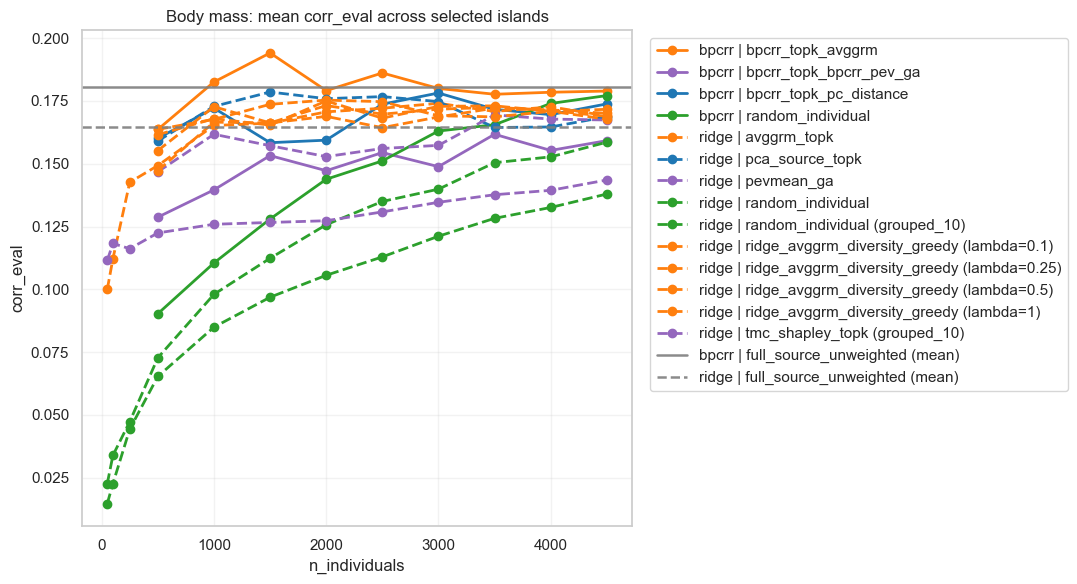

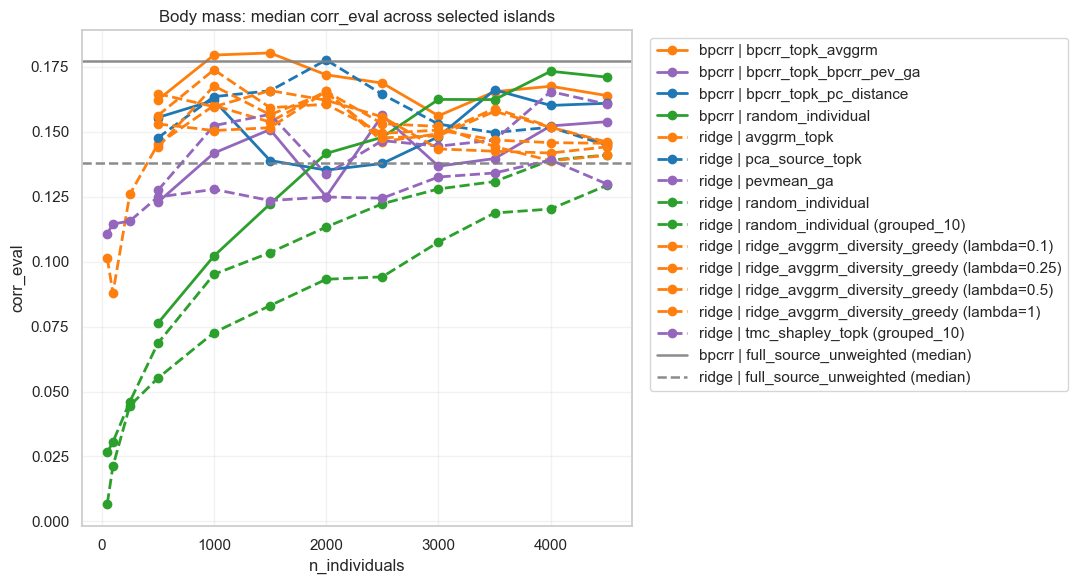

In [30]:
linestyles = ["-", "--", "-.", ":"]


def method_family(method: str) -> str:
    m = str(method).lower()
    if "full_source" in m:
        return "full_source"
    if "random" in m:
        return "random"
    if "avggrm" in m:
        return "avggrm"
    if "delta_ld" in m:
        return "delta_ld"

    # Match PC-based methods explicitly; do not match the "pc" inside "bpcrr".
    pc_tokens = ["pc_distance", "pca_source", "_pc_", "_pca_"]
    if any(tok in m for tok in pc_tokens) or m.startswith("pc_") or m.startswith("pca_"):
        return "pc"

    return "other"


def model_linestyle(model_display: str) -> str:
    return "-" if str(model_display).lower() == "bpcrr" else "--"


family_colors = {
    "random": "#2ca02c",      # green
    "pc": "#1f77b4",          # blue
    "avggrm": "#ff7f0e",      # orange
    "delta_ld": "#d62728",    # red
    "full_source": "#7f7f7f", # gray
    "other": "#9467bd",       # fallback
}

# Figure-1-specific trigger
REMOVE_BPCRR_FROM_FIG1 = False

# Mean corr_eval across selected islands vs n_individuals
plot_df = (
    plot_data.groupby(["model_display", "method", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["model_display", "method", "n_individuals"])
)

if REMOVE_BPCRR_FROM_FIG1:
    plot_df = plot_df[plot_df["model_display"] != "bpcrr"].copy()

if plot_df.empty:
    raise ValueError("No rows to plot after filters. Relax PLOT_MODELS/PLOT_METHODS or USE_RANKED_SUBSET_ONLY.")

plot_df["curve"] = plot_df["model_display"] + " | " + plot_df["method"]
curve_specs = (
    plot_df[["curve", "model_display", "method"]]
    .drop_duplicates()
    .sort_values(["model_display", "method"]) 
)

plt.figure(figsize=(11, 6))
for _, spec in curve_specs.iterrows():
    curve = spec["curve"]
    sub = plot_df[plot_df["curve"] == curve]
    fam = method_family(spec["method"])
    plt.plot(
        sub["n_individuals"],
        sub["corr_eval"],
        marker="o",
        linewidth=2,
        color=family_colors.get(fam, family_colors["other"]),
        linestyle=model_linestyle(spec["model_display"]),
        label=curve,
    )

# Horizontal reference lines: full_source_unweighted mean over selected islands per display model
if not full_source_refs.empty:
    fs_mean = (
        full_source_refs.groupby("model_display", as_index=False)["corr_eval"]
        .mean()
        .sort_values("model_display")
    )
    if REMOVE_BPCRR_FROM_FIG1:
        fs_mean = fs_mean[fs_mean["model_display"] != "bpcrr"]

    for _, row in fs_mean.iterrows():
        plt.axhline(
            row["corr_eval"],
            linestyle=model_linestyle(row["model_display"]),
            linewidth=1.8,
            alpha=0.9,
            color=family_colors["full_source"],
            label=f"{row['model_display']} | full_source_unweighted (mean)",
        )

plt.title("Body mass: mean corr_eval across selected islands")
plt.xlabel("n_individuals")
plt.ylabel("corr_eval")
plt.grid(True, alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Median corr_eval across selected islands vs n_individuals
plot_df_median = (
    plot_data.groupby(["model_display", "method", "n_individuals"], as_index=False)["corr_eval"]
    .median()
    .sort_values(["model_display", "method", "n_individuals"])
)

if REMOVE_BPCRR_FROM_FIG1:
    plot_df_median = plot_df_median[plot_df_median["model_display"] != "bpcrr"].copy()

if plot_df_median.empty:
    raise ValueError("No rows to plot after filters. Relax PLOT_MODELS/PLOT_METHODS or USE_RANKED_SUBSET_ONLY.")

plot_df_median["curve"] = plot_df_median["model_display"] + " | " + plot_df_median["method"]
curve_specs_median = (
    plot_df_median[["curve", "model_display", "method"]]
    .drop_duplicates()
    .sort_values(["model_display", "method"])
)

plt.figure(figsize=(11, 6))
for _, spec in curve_specs_median.iterrows():
    curve = spec["curve"]
    sub = plot_df_median[plot_df_median["curve"] == curve]
    fam = method_family(spec["method"])
    plt.plot(
        sub["n_individuals"],
        sub["corr_eval"],
        marker="o",
        linewidth=2,
        color=family_colors.get(fam, family_colors["other"]),
        linestyle=model_linestyle(spec["model_display"]),
        label=curve,
    )

# Horizontal reference lines: full_source_unweighted median over selected islands per display model
if not full_source_refs.empty:
    fs_median = (
        full_source_refs.groupby("model_display", as_index=False)["corr_eval"]
        .median()
        .sort_values("model_display")
    )
    if REMOVE_BPCRR_FROM_FIG1:
        fs_median = fs_median[fs_median["model_display"] != "bpcrr"]

    for _, row in fs_median.iterrows():
        plt.axhline(
            row["corr_eval"],
            linestyle=model_linestyle(row["model_display"]),
            linewidth=1.8,
            alpha=0.9,
            color=family_colors["full_source"],
            label=f"{row['model_display']} | full_source_unweighted (median)",
        )

plt.title("Body mass: median corr_eval across selected islands")
plt.xlabel("n_individuals")
plt.ylabel("corr_eval")
plt.grid(True, alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Figure 1b: Ridge-only comparison


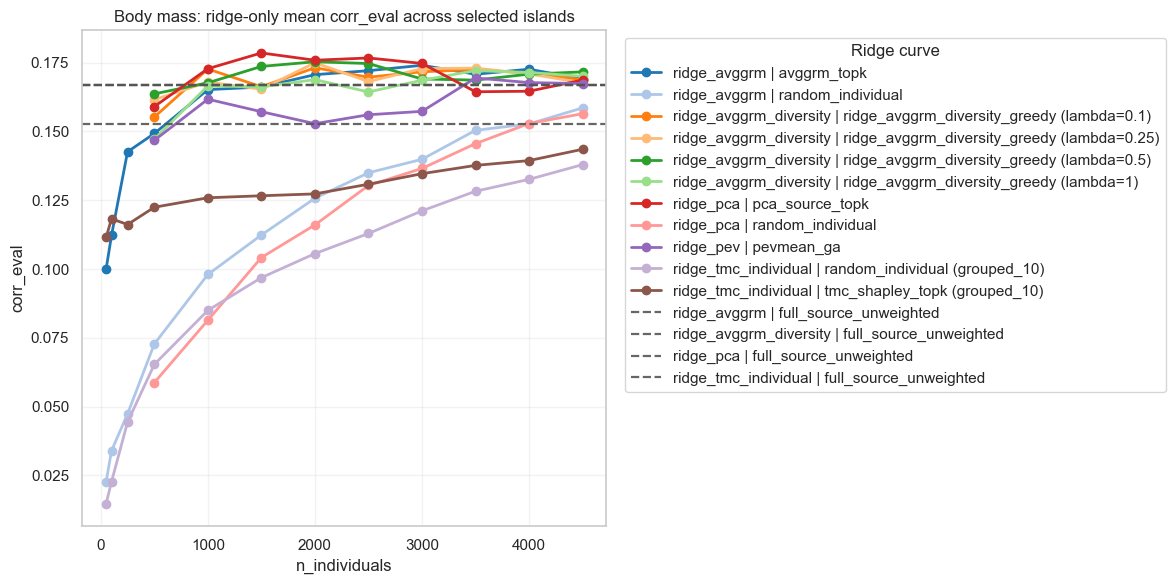

,curve,max_corr,mean_corr
6,ridge_pca | pca_source_topk,0.178548,0.170616
4,ridge_avggrm_diversity | ridge_avggrm_diversit...,0.175328,0.170588
3,ridge_avggrm_diversity | ridge_avggrm_diversit...,0.174985,0.169171
0,ridge_avggrm | avggrm_topk,0.174062,0.155400
2,ridge_avggrm_diversity | ridge_avggrm_diversit...,0.173156,0.169034
5,ridge_avggrm_diversity | ridge_avggrm_diversit...,0.172130,0.166163
8,ridge_pev | pevmean_ga,0.169444,0.159617
1,ridge_avggrm | random_individual,0.158572,0.104117
7,ridge_pca | random_individual,0.156452,0.120235
10,ridge_tmc_individual | tmc_shapley_topk (group...,0.143525,0.127862


In [31]:
# Figure 1b: ridge-only comparison with one color per ridge curve

RIDGE_ONLY_MODELS = [
    "ridge_pca",
    "ridge_avggrm",
    "ridge_pev",
    "ridge_avggrm_diversity",
    "ridge_tmc_individual",
    ]
RIDGE_ONLY_EXCLUDE_METHODS = []

ridge_only = combined.copy()
ridge_only = ridge_only[
    ridge_only["model"].isin(RIDGE_ONLY_MODELS)
    & ridge_only["target_island"].isin(target_islands_to_plot)
].copy()

if "analysis" in ridge_only.columns:
    ranked_or_untyped = ridge_only[(ridge_only["analysis"] == "ranked_subset") | (ridge_only["analysis"].isna())]
    if len(ranked_or_untyped):
        ridge_only = ranked_or_untyped.copy()

ridge_only = ridge_only[ridge_only["method"] != "full_source_unweighted"].copy()
if "order_seed" in ridge_only.columns:
    ridge_only = ridge_only[ridge_only["order_seed"] != -2].copy()
if RIDGE_ONLY_EXCLUDE_METHODS:
    ridge_only = ridge_only[~ridge_only["method"].isin(RIDGE_ONLY_EXCLUDE_METHODS)].copy()

if ridge_only.empty:
    raise ValueError("No ridge rows available for ridge-only plot")

ridge_plot_df = (
    ridge_only.groupby(["model", "method", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["model", "method", "n_individuals"])
)
ridge_plot_df["curve"] = ridge_plot_df["model"] + " | " + ridge_plot_df["method"].astype(str)

curve_order = (
    ridge_plot_df[["curve", "model", "method"]]
    .drop_duplicates()
    .sort_values(["model", "method"])
    ["curve"]
    .tolist()
)
palette = sns.color_palette("tab20", n_colors=max(len(curve_order), 1))
curve_colors = dict(zip(curve_order, palette))

plt.figure(figsize=(12, 6))
for curve in curve_order:
    sub = ridge_plot_df[ridge_plot_df["curve"] == curve]
    plt.plot(
        sub["n_individuals"],
        sub["corr_eval"],
        marker="o",
        linewidth=2,
        color=curve_colors[curve],
        label=curve,
    )

ridge_refs = full_source_refs[
    full_source_refs["model"].isin(RIDGE_ONLY_MODELS)
    & full_source_refs["target_island"].isin(target_islands_to_plot)
].copy()
if not ridge_refs.empty:
    ridge_ref_mean = (
        ridge_refs.groupby("model", as_index=False)["corr_eval"]
        .mean()
        .sort_values("model")
    )
    for _, row in ridge_ref_mean.iterrows():
        label = f"{row['model']} | full_source_unweighted"
        color = curve_colors.get(label, "#555555")
        plt.axhline(
            row["corr_eval"],
            linestyle="--",
            linewidth=1.6,
            alpha=0.9,
            color=color,
            label=label,
        )

plt.title("Body mass: ridge-only mean corr_eval across selected islands")
plt.xlabel("n_individuals")
plt.ylabel("corr_eval")
plt.grid(True, alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Ridge curve")
plt.tight_layout()
plt.show()

ridge_curve_summary = (
    ridge_plot_df.groupby("curve", as_index=False)["corr_eval"]
    .agg(max_corr="max", mean_corr="mean")
    .sort_values("max_corr", ascending=False)
)
display(ridge_curve_summary)


## Figure 1c: Ridge-only mean corr_eval over completed TMC target islands


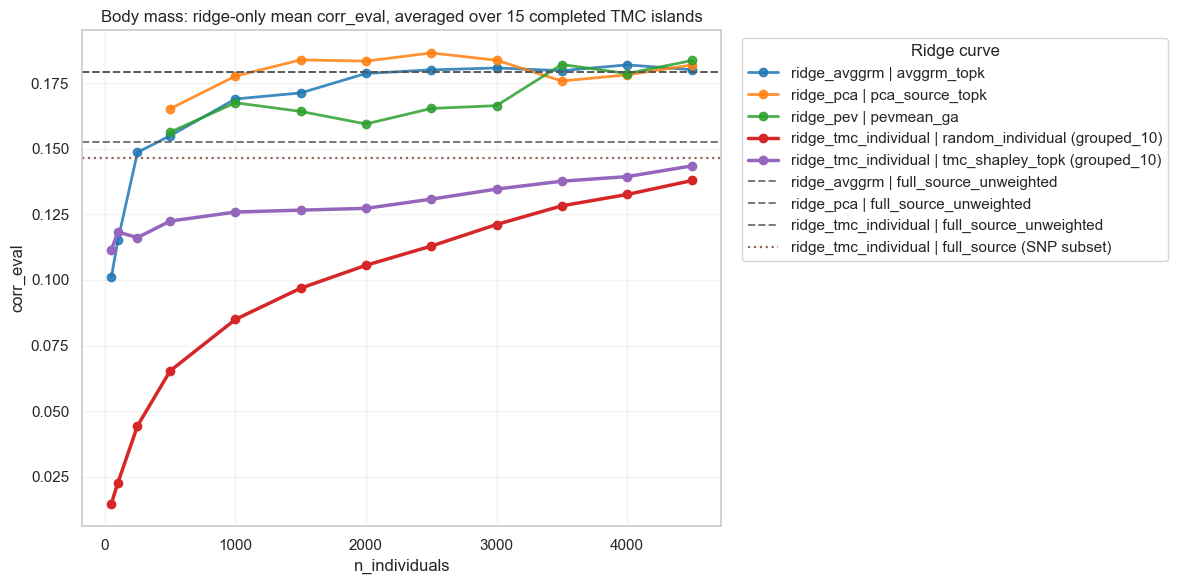

,curve,max_corr,mean_corr
1,ridge_pca | pca_source_topk,0.186575,0.179655
2,ridge_pev | pevmean_ga,0.183704,0.169353
0,ridge_avggrm | avggrm_topk,0.182026,0.161830
4,ridge_tmc_individual | tmc_shapley_topk (group...,0.143525,0.127862
3,ridge_tmc_individual | random_individual (grou...,0.137944,0.088946


In [32]:
# Figure 1c: Ridge-only mean corr_eval averaged over completed TMC target islands.
# Restricts to islands where the grouped TMC run has all 6 repeats finished.

TMC_COMPLETED_ISLANDS = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]

RIDGE_ONLY_MODELS_1c = [
    "ridge_pca",
    "ridge_avggrm",
    "ridge_pev",
    "ridge_tmc_individual",
    ]

ridge_only_1c = combined.copy()
ridge_only_1c = ridge_only_1c[
    ridge_only_1c["model"].isin(RIDGE_ONLY_MODELS_1c)
    & ridge_only_1c["target_island"].isin(TMC_COMPLETED_ISLANDS)
].copy()

if "analysis" in ridge_only_1c.columns:
    ranked_or_untyped = ridge_only_1c[
        (ridge_only_1c["analysis"] == "ranked_subset") | (ridge_only_1c["analysis"].isna())
    ]
    if len(ranked_or_untyped):
        ridge_only_1c = ranked_or_untyped.copy()

ridge_only_1c = ridge_only_1c[ridge_only_1c["method"] != "full_source_unweighted"].copy()
if "order_seed" in ridge_only_1c.columns:
    ridge_only_1c = ridge_only_1c[ridge_only_1c["order_seed"] != -2].copy()

# Drop tmc_shapley_positive marker rows from the curves (shown only in Figure 2).
ridge_only_1c = ridge_only_1c[ridge_only_1c["method"] != "tmc_shapley_positive"].copy()

# Keep random_individual only from ridge_tmc_individual to avoid duplicates.
RANDOM_KEEP_MODELS_1c = {"ridge_tmc_individual"}
mask_drop_rand = (
    (ridge_only_1c["method"] == "random_individual")
    & (~ridge_only_1c["model"].isin(RANDOM_KEEP_MODELS_1c))
)
ridge_only_1c = ridge_only_1c[~mask_drop_rand].copy()

if ridge_only_1c.empty:
    raise ValueError("No ridge rows for the completed TMC subset plot")

# Mean over islands and repeats: first average per (model, method, island, n) to
# get one value per island, then average across islands so each island contributes
# equally regardless of the number of repeats.
per_island = (
    ridge_only_1c.groupby(["model", "method", "target_island", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
)
ridge_plot_df_1c = (
    per_island.groupby(["model", "method", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["model", "method", "n_individuals"])
)
ridge_plot_df_1c["curve"] = ridge_plot_df_1c["model"] + " | " + ridge_plot_df_1c["method"].astype(str)

curve_order_1c = (
    ridge_plot_df_1c[["curve", "model", "method"]]
    .drop_duplicates()
    .sort_values(["model", "method"])
    ["curve"]
    .tolist()
)
palette_1c = sns.color_palette("tab10", n_colors=max(len(curve_order_1c), 1))
curve_colors_1c = dict(zip(curve_order_1c, palette_1c))

plt.figure(figsize=(12, 6))
for curve in curve_order_1c:
    sub = ridge_plot_df_1c[ridge_plot_df_1c["curve"] == curve]
    is_tmc = "tmc_individual" in curve
    lw = 2.5 if is_tmc else 2.0
    plt.plot(
        sub["n_individuals"],
        sub["corr_eval"],
        marker="o",
        linewidth=lw,
        alpha=1.0 if is_tmc else 0.85,
        color=curve_colors_1c[curve],
        label=curve,
    )

ridge_refs_1c = full_source_refs[
    full_source_refs["model"].isin(RIDGE_ONLY_MODELS_1c)
    & full_source_refs["target_island"].isin(TMC_COMPLETED_ISLANDS)
].copy()
if not ridge_refs_1c.empty:
    ridge_ref_mean_1c = (
        ridge_refs_1c.groupby(["model", "target_island"], as_index=False)["corr_eval"]
        .mean()
        .groupby("model", as_index=False)["corr_eval"]
        .mean()
        .sort_values("model")
    )
    for _, row in ridge_ref_mean_1c.iterrows():
        ref_label = f"{row['model']} | full_source_unweighted"
        ref_color = curve_colors_1c.get(ref_label, "#555555")
        plt.axhline(
            row["corr_eval"],
            linestyle="--",
            linewidth=1.4,
            alpha=0.8,
            color=ref_color,
            label=ref_label,
        )

# TMC full-source reference (SNP subset, all source individuals).
if not tmc_individual.empty:
    tmc_full = tmc_individual[
        (tmc_individual["method"] == "full_source_unweighted")
        & (tmc_individual["target_island"].isin(TMC_COMPLETED_ISLANDS))
    ]
    if not tmc_full.empty:
        tmc_full_mean = (
            tmc_full.groupby("target_island")["corr_eval"].mean().mean()
        )
        plt.axhline(
            tmc_full_mean,
            linestyle=":",
            linewidth=1.6,
            alpha=0.9,
            color="#8c564b",
            label="ridge_tmc_individual | full_source (SNP subset)",
        )

n_islands_used = ridge_only_1c["target_island"].nunique()
plt.title(f"Body mass: ridge-only mean corr_eval, averaged over {n_islands_used} completed TMC islands")
plt.xlabel("n_individuals")
plt.ylabel("corr_eval")
plt.grid(True, alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Ridge curve")
plt.tight_layout()
plt.show()

ridge_curve_summary_1c = (
    ridge_plot_df_1c.groupby("curve", as_index=False)["corr_eval"]
    .agg(max_corr="max", mean_corr="mean")
    .sort_values("max_corr", ascending=False)
)
display(ridge_curve_summary_1c)


## TMC Individual Shapley: Statistics on Selected Individuals

Average Shapley phi per source island for each target island (averaged over individuals and repeats). Green bars indicate positive contributions; red indicates negative.

Shapley stats shape: (126, 13)
TMC sources: ['grouped_10']

=== TMC source: grouped_10 ===


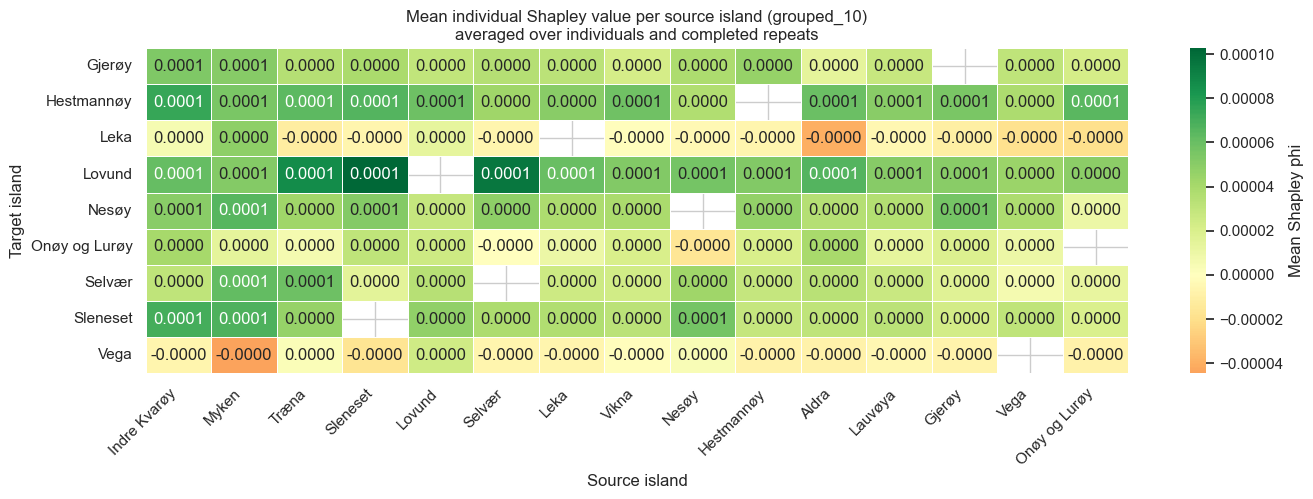

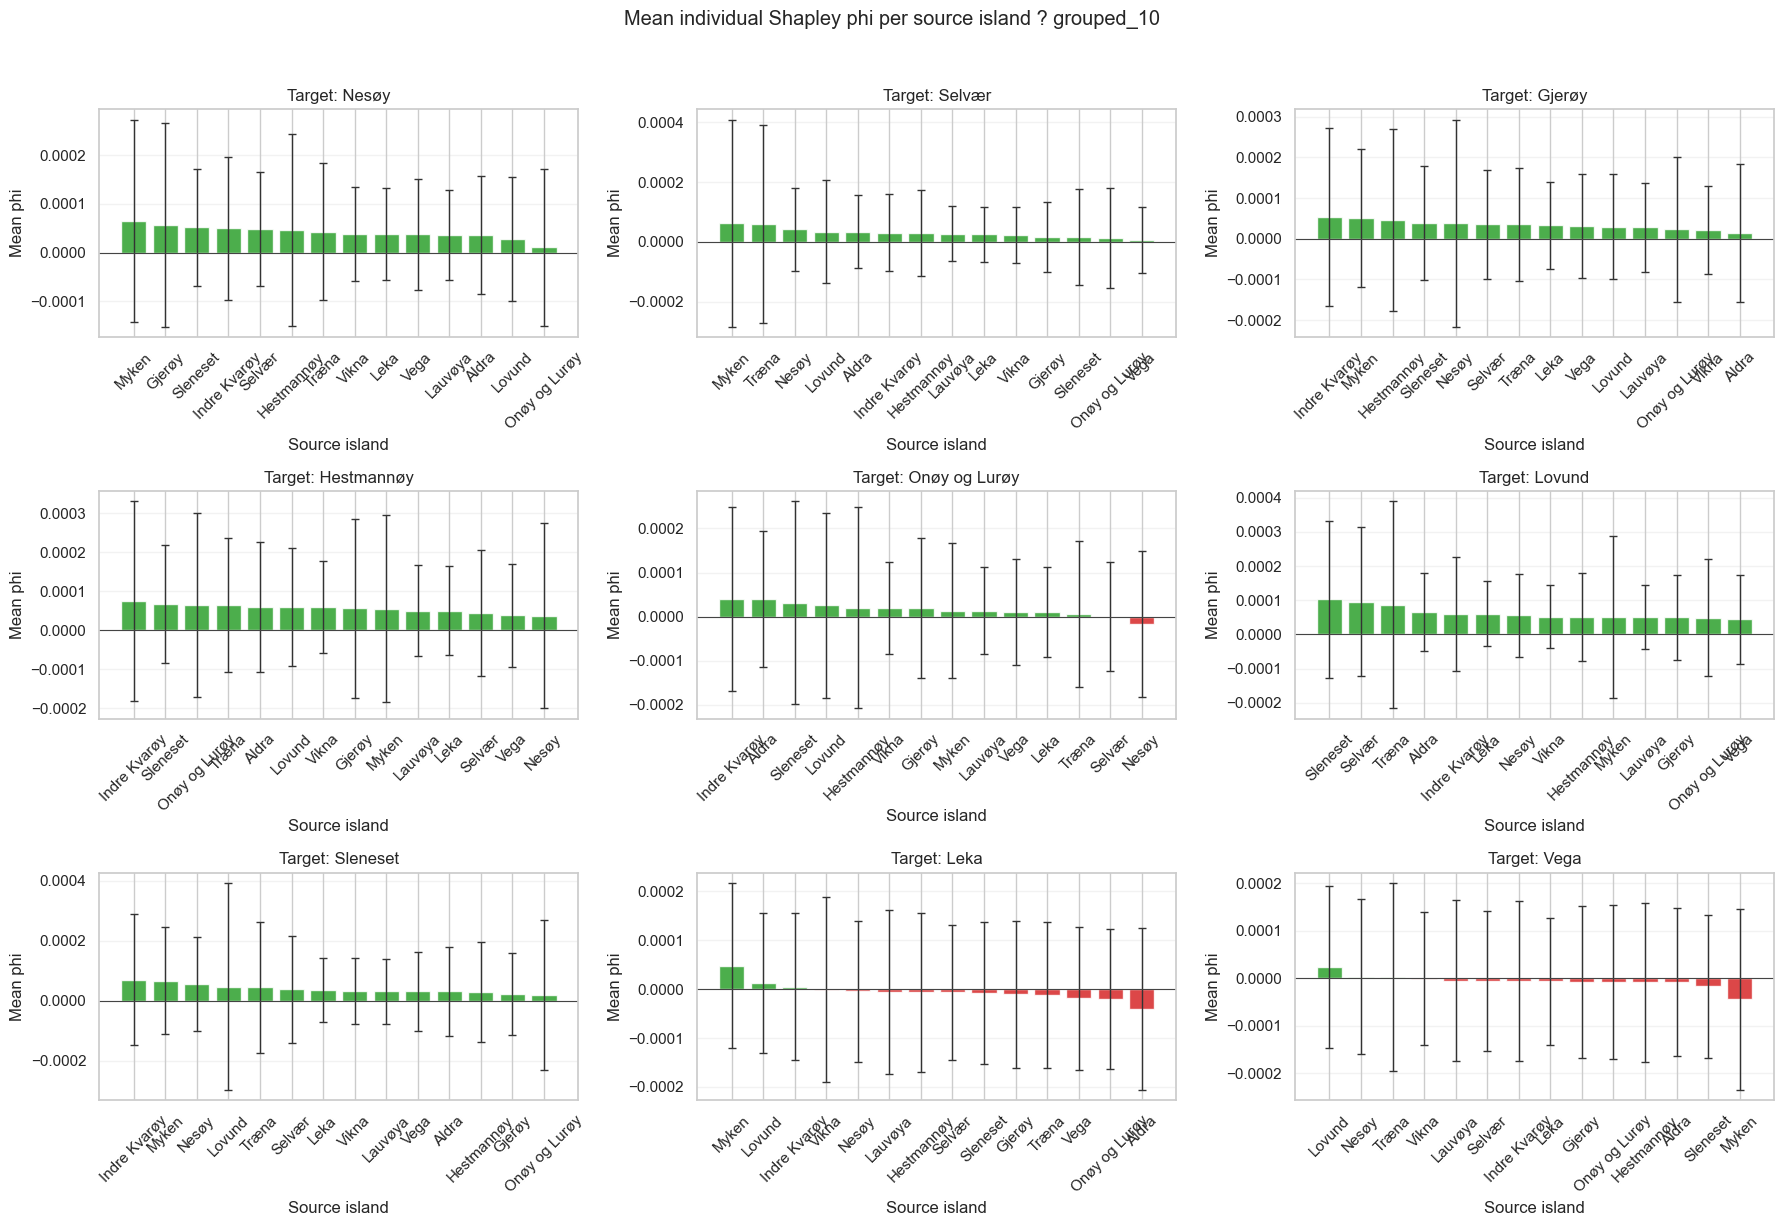

Top source islands by mean Shapley phi (per target island):

Nesøy (island 0):


,source_island_name,phi_mean,phi_std,n_individuals,n_repeats
0,Myken,0.000065,0.000508,552,6
1,Gjerøy,0.000057,0.000511,3348,6
2,Sleneset,0.000052,0.000295,996,6
3,Indre Kvarøy,0.000050,0.000359,2136,6
4,Selvær,0.000048,0.000285,1164,6
5,Hestmannøy,0.000047,0.000481,6468,6
6,Træna,0.000043,0.000344,1752,6
7,Vikna,0.000039,0.000236,3504,6



Selvær (island 3):


,source_island_name,phi_mean,phi_std,n_individuals,n_repeats
14,Myken,0.000062,0.000848,552,6
15,Træna,0.000059,0.000812,1752,6
16,Nesøy,0.000043,0.000340,714,6
17,Lovund,0.000034,0.000424,948,6
18,Aldra,0.000033,0.000299,1038,6
19,Indre Kvarøy,0.000031,0.000316,2136,6
20,Hestmannøy,0.000029,0.000353,6468,6
21,Lauvøya,0.000027,0.000226,4128,6



Gjerøy (island 4):


...

,source_island_name,phi_mean,phi_std,n_individuals,n_repeats
84,Indre Kvarøy,0.000071,0.000538,2136,6
85,Myken,0.000068,0.000435,552,6
86,Nesøy,0.000057,0.000384,714,6
87,Lovund,0.000048,0.000846,948,6
88,Træna,0.000046,0.000535,1752,6
89,Selvær,0.000038,0.000437,1164,6
90,Leka,0.000037,0.000263,3498,6
91,Vikna,0.000033,0.000268,3504,6



Leka (island 11):


,source_island_name,phi_mean,phi_std,n_individuals,n_repeats
98,Myken,0.000048,0.000414,552,6
99,Lovund,0.000013,0.000352,948,6
100,Indre Kvarøy,0.000005,0.000369,2136,6
101,Vikna,-0.000001,0.000463,3504,6
102,Nesøy,-0.000005,0.000355,714,6
103,Lauvøya,-0.000005,0.000411,4128,6
104,Hestmannøy,-0.000006,0.000398,6468,6
105,Selvær,-0.000006,0.000339,1164,6



Vega (island 12):


,source_island_name,phi_mean,phi_std,n_individuals,n_repeats
112,Lovund,0.000024,0.000418,948,6
113,Nesøy,0.000004,0.000400,714,6
114,Træna,0.000003,0.000484,1752,6
115,Vikna,-0.000001,0.000342,3504,6
116,Lauvøya,-0.000005,0.000414,4128,6
117,Selvær,-0.000006,0.000359,1164,6
118,Indre Kvarøy,-0.000006,0.000414,2136,6
119,Leka,-0.000007,0.000328,3498,6


In [33]:
# TMC Individual Shapley statistics: mean phi per source island per target/source

if tmc_individual_shap_stats.empty:
    print("No Shapley source-island stats loaded ? run run_tmc_individual_topk_eval.py first.")
else:
    stats = tmc_individual_shap_stats.copy()
    if "tmc_source" not in stats.columns:
        stats["tmc_source"] = "individual"
    print("Shapley stats shape:", stats.shape)
    print("TMC sources:", sorted(stats["tmc_source"].unique().tolist()))

    for source_name in sorted(stats["tmc_source"].unique().tolist()):
        source_stats = stats[stats["tmc_source"] == source_name].copy()
        print(f"\n=== TMC source: {source_name} ===")

        # Heatmap: rows = target islands, cols = source islands, values = phi_mean
        pivot = source_stats.pivot_table(
            index="target_island_name",
            columns="source_island_name",
            values="phi_mean",
            aggfunc="mean",
        )
        col_order = pivot.mean(axis=0).sort_values(ascending=False).index.tolist()
        pivot = pivot[col_order]

        fig, ax = plt.subplots(figsize=(14, max(4, 0.35 * len(pivot) + 2)))
        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdYlGn",
            center=0,
            annot=True,
            fmt=".4f",
            linewidths=0.4,
            cbar_kws={"label": "Mean Shapley phi"},
        )
        ax.set_title(
            f"Mean individual Shapley value per source island ({source_name})\n"
            "averaged over individuals and completed repeats"
        )
        ax.set_xlabel("Source island")
        ax.set_ylabel("Target island")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        # Per-target bar plots
        target_codes_stats = sorted(source_stats["target_island"].unique())
        n_cols_s = min(3, len(target_codes_stats))
        n_rows_s = int(np.ceil(len(target_codes_stats) / n_cols_s))
        fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(6 * n_cols_s, 4 * n_rows_s))
        axes = np.array(axes).reshape(n_rows_s, n_cols_s)

        for i, target_code in enumerate(target_codes_stats):
            r, c = divmod(i, n_cols_s)
            ax = axes[r, c]
            sub = source_stats[source_stats["target_island"] == target_code].sort_values("phi_mean", ascending=False)
            target_name_s = sub["target_island_name"].iloc[0] if not sub.empty else str(target_code)
            bar_colors = ["#d62728" if v < 0 else "#2ca02c" for v in sub["phi_mean"]]
            ax.bar(sub["source_island_name"], sub["phi_mean"], color=bar_colors, alpha=0.85, edgecolor="white")
            ax.errorbar(
                sub["source_island_name"],
                sub["phi_mean"],
                yerr=sub["phi_std"] / np.sqrt(sub["n_repeats"].clip(lower=1)),
                fmt="none",
                color="#333",
                capsize=3,
                linewidth=1,
            )
            ax.axhline(0, color="#444", linewidth=0.8)
            ax.set_title(f"Target: {target_name_s}")
            ax.set_xlabel("Source island")
            ax.set_ylabel("Mean phi")
            ax.tick_params(axis="x", rotation=45)
            ax.grid(axis="y", alpha=0.25)

        for j in range(len(target_codes_stats), n_rows_s * n_cols_s):
            r, c = divmod(j, n_cols_s)
            axes[r, c].axis("off")

        fig.suptitle(f"Mean individual Shapley phi per source island ? {source_name}", y=1.02)
        fig.tight_layout()
        plt.show()

        print("Top source islands by mean Shapley phi (per target island):")
        for target_code in sorted(source_stats["target_island"].unique()):
            sub = source_stats[source_stats["target_island"] == target_code].sort_values("phi_mean", ascending=False)
            tname = sub["target_island_name"].iloc[0]
            print(f"\n{tname} (island {target_code}):")
            display(sub[["source_island_name", "phi_mean", "phi_std", "n_individuals", "n_repeats"]].head(8))


## TMC Individual Shapley: Evaluation Counts


Per-repeat evaluation counts:


,tmc_source,target_island,target_island_name,repeat,n_players,n_permutations,n_truncated,n_utility_evals,group_size,mean_prefix_individuals_per_permutation,evals_per_individual_mean,evals_per_individual_std,evals_per_individual_min,evals_per_individual_max
0,grouped_10,0,Nesøy,0,5578,300,300,83130,10,2770.966667,149.024023,6.400559,124.0,176.0
1,grouped_10,0,Nesøy,1,5578,300,300,76168,10,2538.900000,136.542488,6.369134,113.0,163.0
2,grouped_10,0,Nesøy,2,5578,300,300,77164,10,2572.100000,138.329509,6.454385,112.0,165.0
3,grouped_10,0,Nesøy,3,5578,300,300,102434,10,3414.433333,183.628899,6.608987,161.0,207.0
4,grouped_10,0,Nesøy,4,5578,300,300,103106,10,3436.833333,184.832198,6.434558,159.0,207.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,grouped_10,14,Lauvøya,1,5009,300,300,96779,10,3225.933333,193.196646,5.885771,170.0,228.0
79,grouped_10,14,Lauvøya,2,5009,300,300,87030,10,2900.966667,173.736075,5.975579,152.0,197.0
80,grouped_10,14,Lauvøya,3,5009,300,300,75614,10,2520.433333,150.948293,6.385837,127.0,176.0
81,grouped_10,14,Lauvøya,4,5009,300,300,86434,10,2881.100000,172.549810,6.501007,146.0,195.0


Average evaluation counts by TMC source:


,tmc_source,n_targets,n_repeats,total_utility_evals,mean_utility_evals_per_repeat,mean_prefix_individuals_per_permutation,mean_evals_per_individual,median_evals_per_individual,min_repeat_mean_evals_per_individual,max_repeat_mean_evals_per_individual
0,grouped_10,15,83,7378559,88898.301205,2963.243373,167.773378,162.827937,130.677379,248.239446


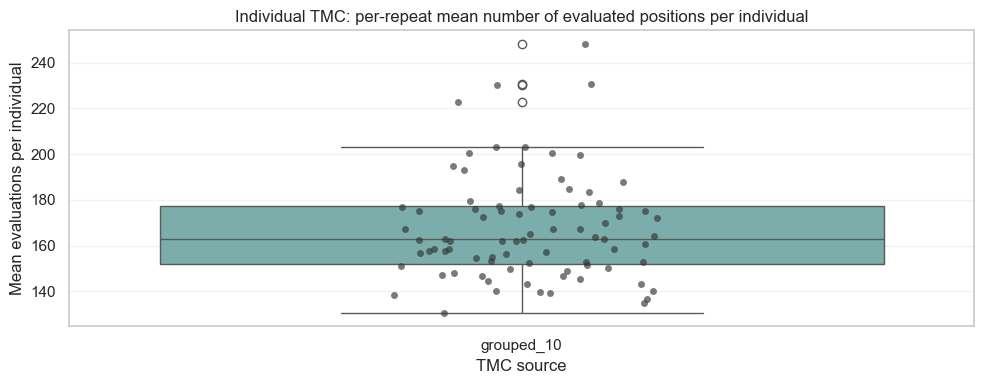

In [34]:
# How often individuals were evaluated during individual TMC

if tmc_eval_stats.empty:
    print("No TMC evaluation-count summaries found.")
else:
    eval_stats = tmc_eval_stats.copy()
    display_cols = [
        "tmc_source",
        "target_island",
        "target_island_name",
        "repeat",
        "n_players",
        "n_permutations",
        "n_truncated",
        "n_utility_evals",
        "group_size",
        "mean_prefix_individuals_per_permutation",
        "evals_per_individual_mean",
        "evals_per_individual_std",
        "evals_per_individual_min",
        "evals_per_individual_max",
    ]
    print("Per-repeat evaluation counts:")
    display(eval_stats[display_cols].sort_values(["tmc_source", "target_island", "repeat"]))

    eval_summary = (
        eval_stats
        .groupby("tmc_source", as_index=False)
        .agg(
            n_targets=("target_island", "nunique"),
            n_repeats=("repeat", "size"),
            total_utility_evals=("n_utility_evals", "sum"),
            mean_utility_evals_per_repeat=("n_utility_evals", "mean"),
            mean_prefix_individuals_per_permutation=("mean_prefix_individuals_per_permutation", "mean"),
            mean_evals_per_individual=("evals_per_individual_mean", "mean"),
            median_evals_per_individual=("evals_per_individual_mean", "median"),
            min_repeat_mean_evals_per_individual=("evals_per_individual_mean", "min"),
            max_repeat_mean_evals_per_individual=("evals_per_individual_mean", "max"),
        )
        .sort_values("tmc_source")
    )
    print("Average evaluation counts by TMC source:")
    display(eval_summary)

    plt.figure(figsize=(10, 4))
    sns.boxplot(
        data=eval_stats,
        x="tmc_source",
        y="evals_per_individual_mean",
        color="#72B7B2",
    )
    sns.stripplot(
        data=eval_stats,
        x="tmc_source",
        y="evals_per_individual_mean",
        color="#333333",
        alpha=0.65,
        jitter=0.15,
    )
    plt.ylabel("Mean evaluations per individual")
    plt.xlabel("TMC source")
    plt.title("Individual TMC: per-repeat mean number of evaluated positions per individual")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## Figure 2: Ridge-only per-island grid (completed TMC islands)


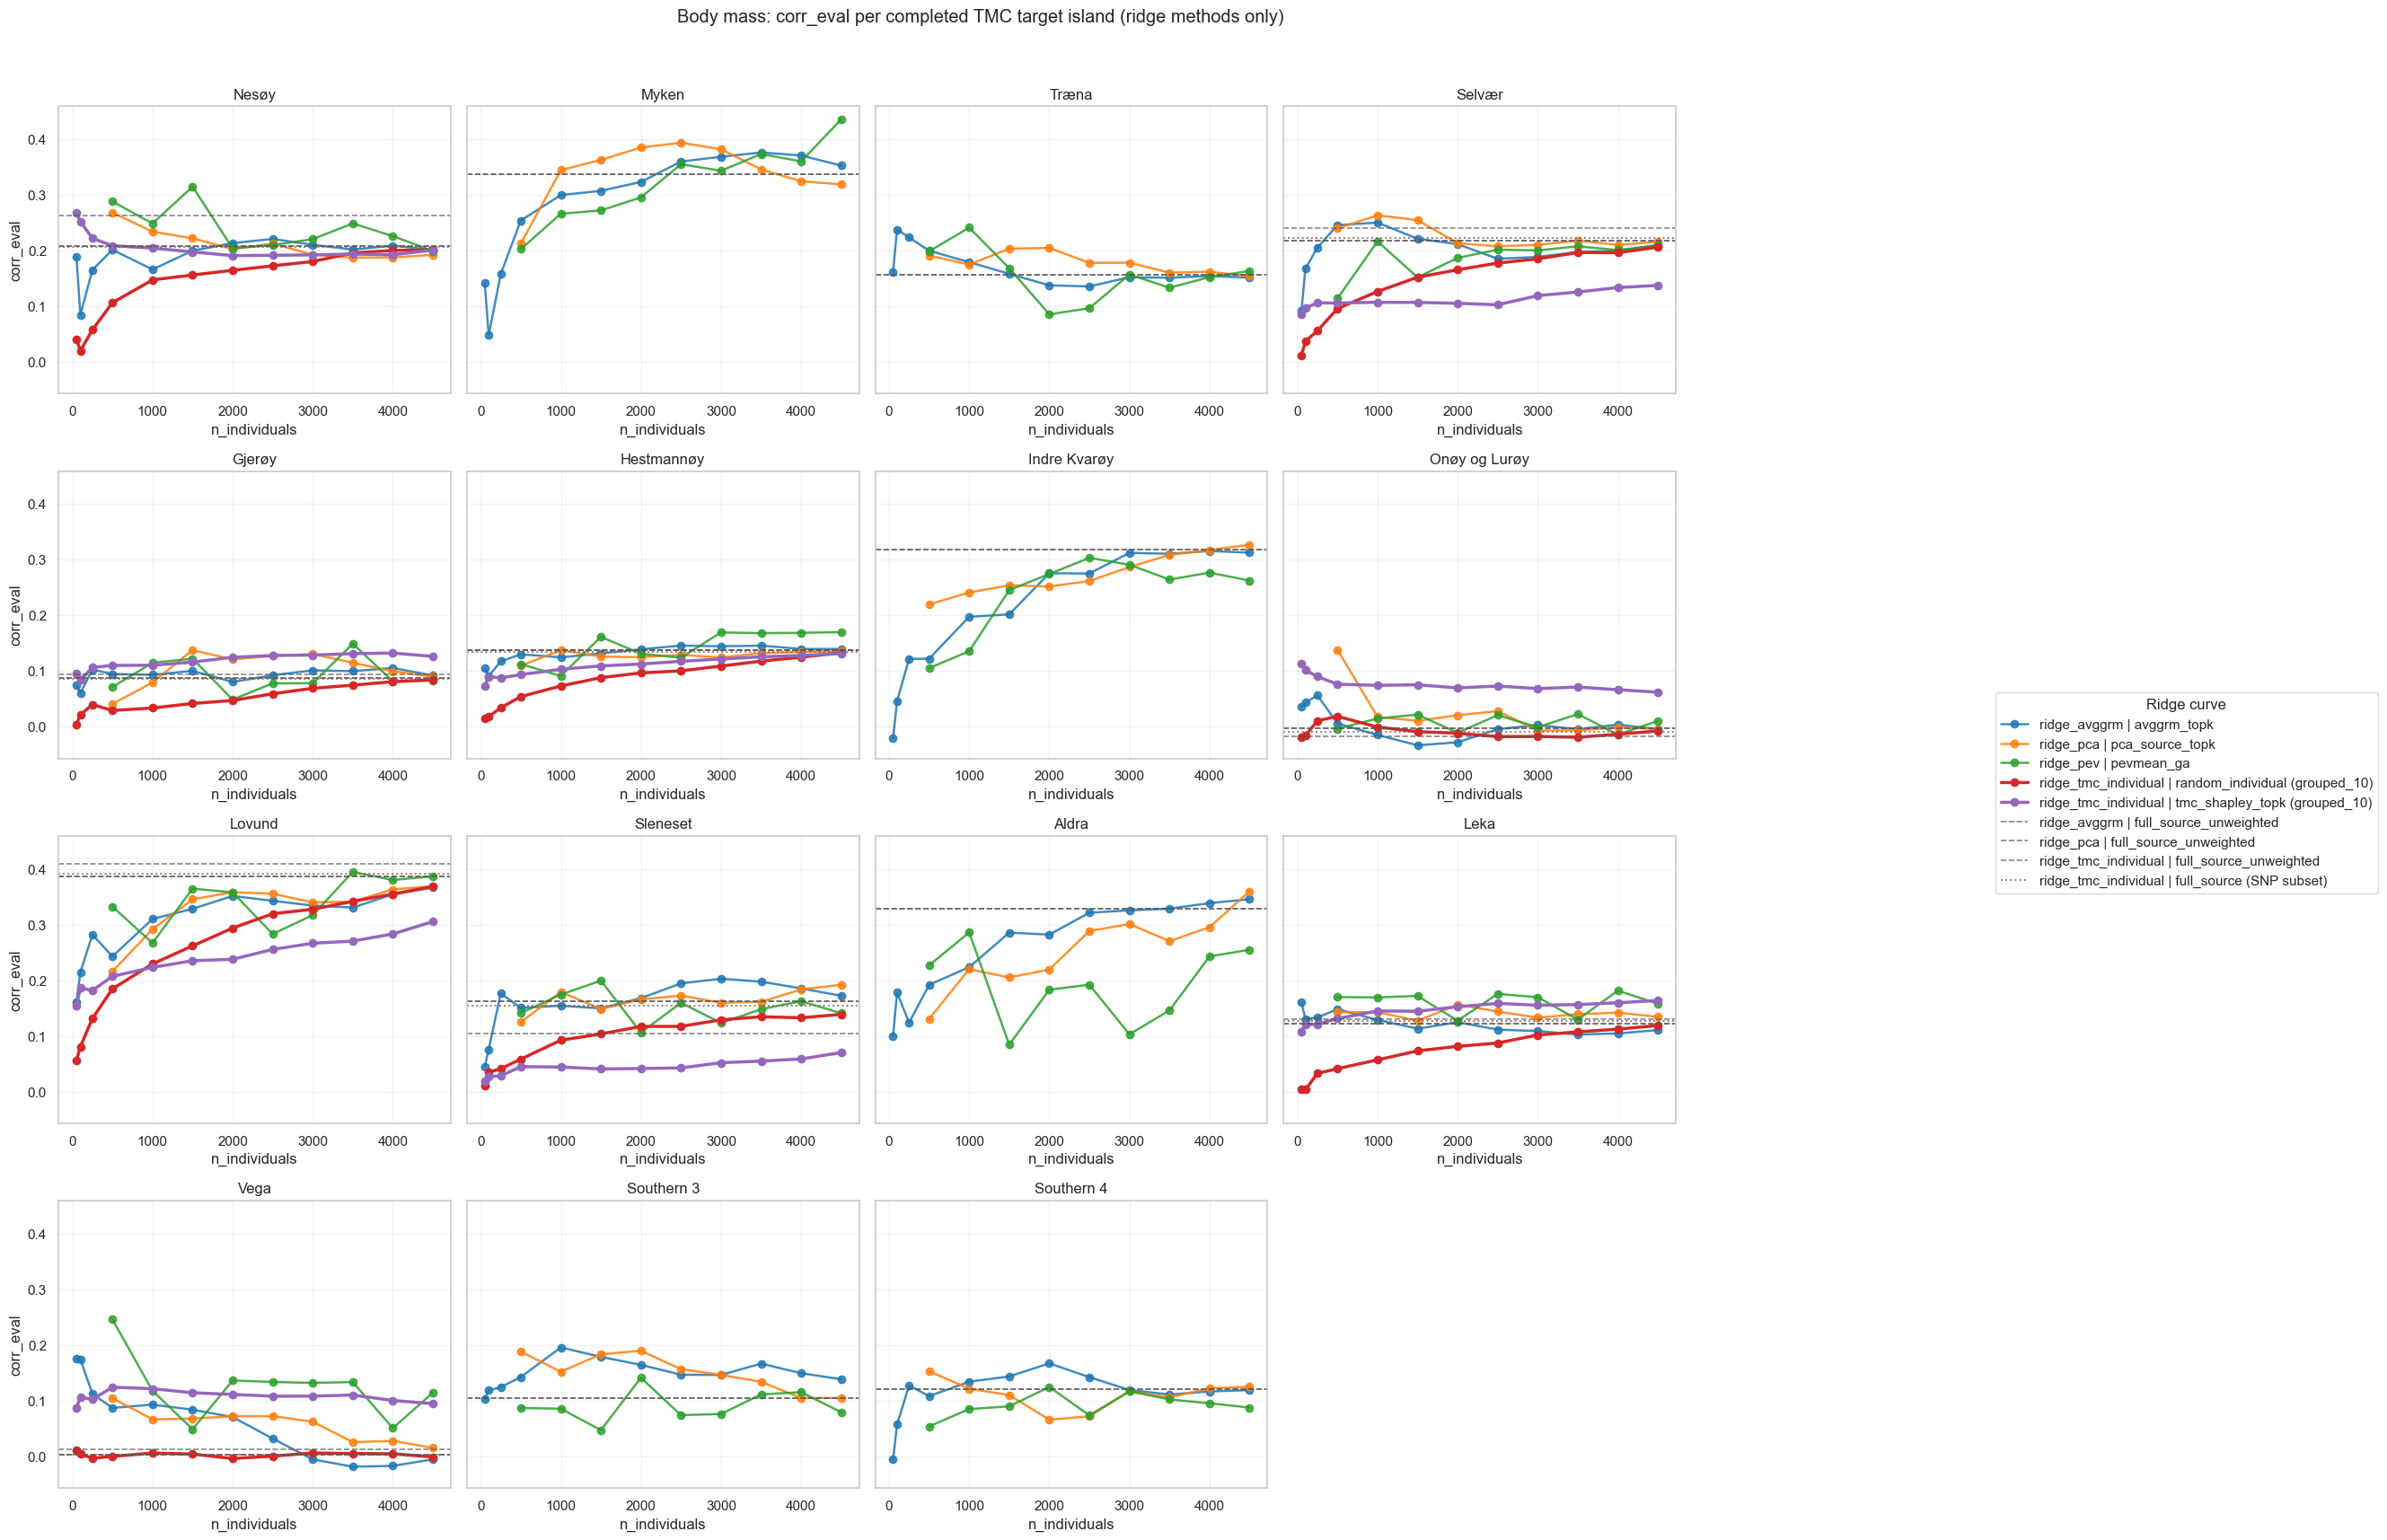

In [40]:
# Figure 2: ridge-only grid, one panel per completed TMC target island.

TMC_COMPLETED_ISLANDS = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]

RIDGE_ONLY_MODELS_F2 = [
    "ridge_pca",
    "ridge_avggrm",
    "ridge_pev",
    "ridge_tmc_individual",
    ]

panel_df = combined.copy()
panel_df = panel_df[
    panel_df["model"].isin(RIDGE_ONLY_MODELS_F2)
    & panel_df["target_island"].isin(TMC_COMPLETED_ISLANDS)
].copy()

if "analysis" in panel_df.columns:
    ranked_or_untyped = panel_df[(panel_df["analysis"] == "ranked_subset") | (panel_df["analysis"].isna())]
    if len(ranked_or_untyped):
        panel_df = ranked_or_untyped.copy()

panel_df = panel_df[panel_df["method"] != "full_source_unweighted"].copy()
if "order_seed" in panel_df.columns:
    panel_df = panel_df[panel_df["order_seed"] != -2].copy()

panel_df = panel_df[panel_df["method"] != "tmc_shapley_positive"].copy()

# Keep random only from ridge_tmc_individual.
RANDOM_KEEP_F2 = {"ridge_tmc_individual"}
mask_drop_rand = (
    (panel_df["method"] == "random_individual")
    & (~panel_df["model"].isin(RANDOM_KEEP_F2))
)
panel_df = panel_df[~mask_drop_rand].copy()

panel_plot_df = (
    panel_df.groupby(["target_island", "model", "method", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["target_island", "model", "method", "n_individuals"])
)
panel_plot_df["curve"] = panel_plot_df["model"] + " | " + panel_plot_df["method"].astype(str)

if panel_plot_df.empty:
    raise ValueError("No ridge rows for per-island grid")

curve_order_f2 = (
    panel_plot_df[["curve", "model", "method"]]
    .drop_duplicates()
    .sort_values(["model", "method"])
    ["curve"]
    .tolist()
)
palette_f2 = sns.color_palette("tab10", n_colors=max(len(curve_order_f2), 1))
curve_colors_f2 = dict(zip(curve_order_f2, palette_f2))

# Try to use real island names if available.
island_name_map = {}
for col in ["target_island_name", "target_name", "island_name", "target_island_label"]:
    if col in combined.columns:
        name_df = combined[["target_island", col]].dropna().drop_duplicates()
        if not name_df.empty:
            island_name_map = dict(zip(name_df["target_island"].astype(int), name_df[col].astype(str)))
            break


def island_title(island_id: int) -> str:
    n = island_name_map.get(int(island_id))
    return n if n else f"Target island {island_id}"


islands = sorted(panel_plot_df["target_island"].unique().tolist())
n = len(islands)
n_cols = min(4, n)
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows), sharey=True)
axes = np.array(axes).reshape(n_rows, n_cols)

panel_full_source_refs = full_source_refs.copy()
panel_full_source_refs = panel_full_source_refs[
    panel_full_source_refs["model"].isin(RIDGE_ONLY_MODELS_F2)
    & panel_full_source_refs["target_island"].isin(TMC_COMPLETED_ISLANDS)
]

for i, island in enumerate(islands):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]
    sub = panel_plot_df[panel_plot_df["target_island"] == island]

    for curve in curve_order_f2:
        s = sub[sub["curve"] == curve]
        if s.empty:
            continue
        is_tmc = "tmc_individual" in curve
        ax.plot(
            s["n_individuals"],
            s["corr_eval"],
            marker="o",
            linewidth=2.5 if is_tmc else 1.8,
            alpha=1.0 if is_tmc else 0.85,
            color=curve_colors_f2[curve],
            label=curve,
        )

    # Per-model full-source hlines.
    fs_island = panel_full_source_refs[panel_full_source_refs["target_island"] == island]
    if not fs_island.empty:
        fs_model = fs_island.groupby("model", as_index=False)["corr_eval"].mean()
        for _, row in fs_model.iterrows():
            ref_label = f"{row['model']} | full_source_unweighted"
            ax.axhline(
                row["corr_eval"],
                linestyle="--",
                linewidth=1.2,
                alpha=0.7,
                color=curve_colors_f2.get(ref_label, "#555555"),
                label=ref_label,
            )

    # TMC full-source baseline for this island (SNP subset).
    if not tmc_individual.empty:
        tmc_full_isl = tmc_individual[
            (tmc_individual["method"] == "full_source_unweighted")
            & (tmc_individual["target_island"] == island)
        ]
        if not tmc_full_isl.empty:
            ax.axhline(
                tmc_full_isl["corr_eval"].mean(),
                linestyle=":",
                linewidth=1.4,
                alpha=0.8,
                color="#8c564b",
                label="ridge_tmc_individual | full_source (SNP subset)",
            )

    ax.set_title(island_title(island))
    ax.set_xlabel("n_individuals")
    if c == 0:
        ax.set_ylabel("corr_eval")
    ax.grid(True, alpha=0.25)

for j in range(n, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis("off")

# Collect legend handles from any populated axis.
handles, labels = [], []
for ax in axes.flatten():
    h, l = ax.get_legend_handles_labels()
    if l:
        handles, labels = h, l
        break
if handles:
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    fig.legend(
        list(uniq.values()),
        list(uniq.keys()),
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title="Ridge curve",
    )

fig.suptitle("Body mass: corr_eval per completed TMC target island (ridge methods only)", y=1.02)
fig.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()


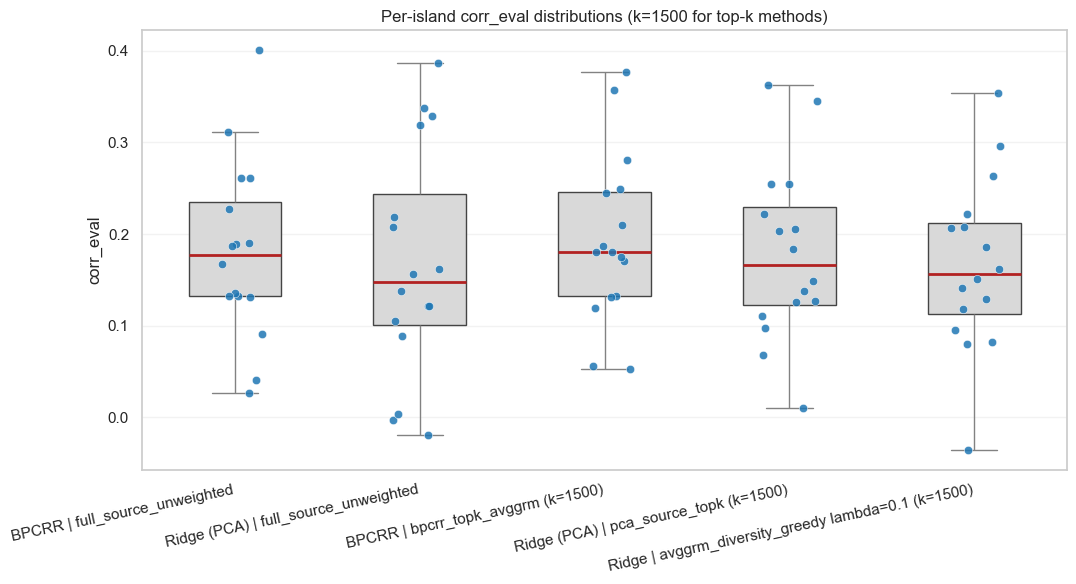

,index,box,n_islands,mean,median,std
0,0,BPCRR | bpcrr_topk_avggrm (k=1500),16,0.194102,0.180394,0.092006
1,1,BPCRR | full_source_unweighted,16,0.180368,0.177154,0.097138
2,2,Ridge (PCA) | full_source_unweighted,16,0.167013,0.147310,0.125603
3,3,Ridge (PCA) | pca_source_topk (k=1500),16,0.178548,0.165826,0.095318
4,4,Ridge | avggrm_diversity_greedy lambda=0.1 (k=...,16,0.166253,0.156612,0.094156


In [41]:
# Figure 3: Boxplots of per-island performance for selected settings

# One point in each box = one target island (mean corr_eval within island if duplicates exist).
K_VALUE = 1500

box_specs = [
    {
        "label": "BPCRR | full_source_unweighted",
        "model": "bpcrr",
        "method": "full_source_unweighted",
        "n_individuals": None,
    },
    {
        "label": "Ridge (PCA) | full_source_unweighted",
        "model": "ridge_pca",
        "method": "full_source_unweighted",
        "n_individuals": None,
    },
    {
        "label": f"BPCRR | bpcrr_topk_avggrm (k={K_VALUE})",
        "model": "bpcrr",
        "method": "bpcrr_topk_avggrm",
        "n_individuals": K_VALUE,
    },
    {
        "label": f"Ridge (PCA) | pca_source_topk (k={K_VALUE})",
        "model": "ridge_pca",
        "method": "pca_source_topk",
        "n_individuals": K_VALUE,
    },
    {
        "label": f"Ridge | avggrm_diversity_greedy lambda=0.1 (k={K_VALUE})",
        "model": "ridge_avggrm_diversity",
        "method": "ridge_avggrm_diversity_greedy (lambda=0.1)",
        "n_individuals": K_VALUE,
    },
]

def collect_box_points(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    sub = df[(df["model"] == spec["model"]) & (df["method"] == spec["method"])].copy()

    if spec["n_individuals"] is not None:
        sub = sub[sub["n_individuals"] == spec["n_individuals"]]

    # Keep only target islands we currently focus on (same selection as earlier figures).
    sub = sub[sub["target_island"].isin(target_islands_to_plot)]

    if sub.empty:
        return pd.DataFrame(columns=["target_island", "corr_eval", "box"])

    # One point per island for the boxplot.
    points = sub.groupby("target_island", as_index=False)["corr_eval"].mean()
    points["box"] = spec["label"]
    return points

box_parts = [collect_box_points(combined, spec) for spec in box_specs]
box_df = pd.concat(box_parts, ignore_index=True)

if box_df.empty:
    raise ValueError("No rows found for the requested boxplot settings.")

# Enforce order even if some boxes are empty/missing.
box_order = [spec["label"] for spec in box_specs]
present_order = [label for label in box_order if label in box_df["box"].unique()]

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=box_df,
    x="box",
    y="corr_eval",
    order=present_order,
    color="#d9d9d9",
    width=0.5,
    showfliers=False,
    boxprops={"edgecolor": "#444444"},
    medianprops={"color": "#b22222", "linewidth": 2},
)

sns.stripplot(
    data=box_df,
    x="box",
    y="corr_eval",
    order=present_order,
    color="#1f77b4",
    size=6,
    alpha=0.85,
    jitter=0.15,
    edgecolor="white",
    linewidth=0.4,
)

plt.title(f"Per-island corr_eval distributions (k={K_VALUE} for top-k methods)")
plt.xlabel("")
plt.ylabel("corr_eval")
plt.xticks(rotation=12, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

summary = (
    box_df.groupby("box", as_index=False)["corr_eval"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .rename(columns={"count": "n_islands"})
)
display(summary)

Loaded BPCRR rank-weight results: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_rank_weight\bpcrr_inla_rank_weight_results.csv (94, 16)
Schemes in plot: ['exp_beta_0p5', 'exp_beta_1p0', 'exp_beta_2p0', 'exp_beta_4p0', 'uniform', 'unweighted']
Common islands across all schemes: 15
Dropped islands (not present in all schemes): [np.int64(15)]


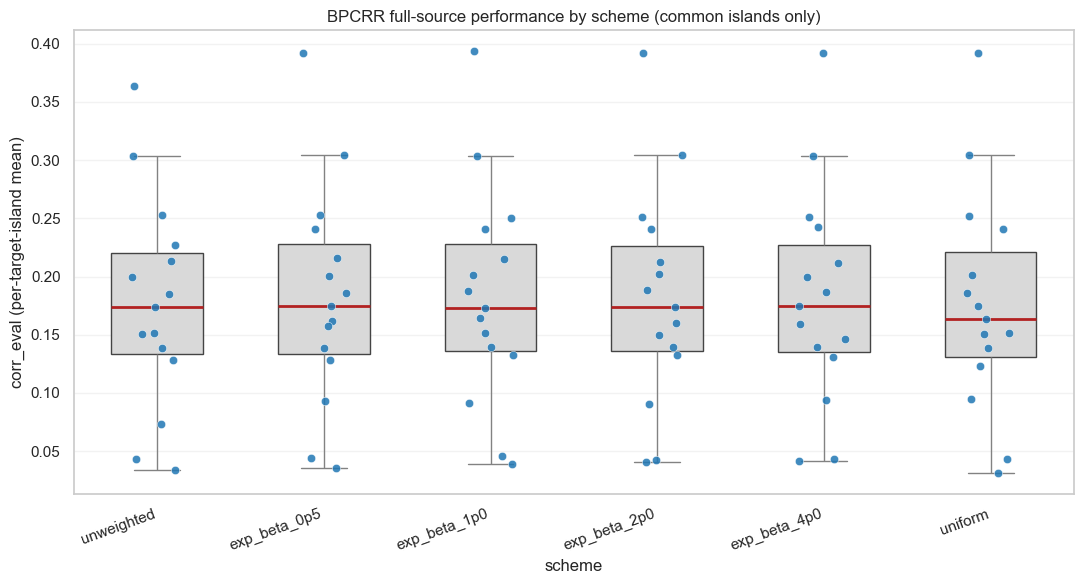

,scheme_plot,n_islands,mean,median,std
1,exp_beta_1p0,15,0.181973,0.172782,0.093360
0,exp_beta_0p5,15,0.181750,0.174685,0.093817
2,exp_beta_2p0,15,0.181345,0.173939,0.093494
3,exp_beta_4p0,15,0.181119,0.174305,0.093154
4,uniform,15,0.176489,0.163913,0.094389
5,unweighted,15,0.175837,0.174141,0.090840


In [42]:
# Figure 4: BPCRR weighted-full boxplots (common islands only, incl. unweighted)

BPCRR_WEIGHT_DIR = PROJECT_ROOT / "outputs" / "bpcrr_inla_rank_weight"
bpcrr_weight_path = _find_csv(BPCRR_WEIGHT_DIR, "bpcrr_inla_rank_weight_results.csv")

if bpcrr_weight_path is None:
    raise FileNotFoundError("Could not find bpcrr_inla_rank_weight_results.csv under BPCRR_WEIGHT_DIR")

bpcrr_weight = _load_and_standardize(bpcrr_weight_path, "bpcrr_weight")
print("Loaded BPCRR rank-weight results:", bpcrr_weight_path, bpcrr_weight.shape)

if "analysis" in bpcrr_weight.columns:
    scheme_df = bpcrr_weight[bpcrr_weight["analysis"].isin(["weighted_full", "full_baseline"])].copy()
else:
    scheme_df = bpcrr_weight.copy()

if scheme_df.empty:
    raise ValueError("No weighted_full/full_baseline rows found in BPCRR rank-weight results")

if "weight_scheme" not in scheme_df.columns:
    scheme_df["weight_scheme"] = (
        scheme_df["method"].astype(str)
        .str.replace("bpcrr_weight_", "", regex=False)
        .replace({"full_source_unweighted": "none"})
    )

# Create a plotting scheme label and ensure baseline is explicitly called 'unweighted'.
scheme_df["scheme_plot"] = scheme_df["weight_scheme"].astype(str)
if "analysis" in scheme_df.columns:
    scheme_df.loc[scheme_df["analysis"] == "full_baseline", "scheme_plot"] = "unweighted"
scheme_df.loc[scheme_df["scheme_plot"].str.lower().isin(["none", "nan"]), "scheme_plot"] = "unweighted"

# Keep same island scope as the rest of the notebook.
scheme_df = scheme_df[scheme_df["target_island"].isin(target_islands_to_plot)].copy()

# One point per target island and scheme (mean over repeats / n_components if duplicated).
scheme_points = (
    scheme_df.groupby(["scheme_plot", "target_island"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["scheme_plot", "target_island"])
)

if scheme_points.empty:
    raise ValueError("No rows available for weighted-scheme boxplot")

# Restrict to islands that are present for every scheme.
wide = scheme_points.pivot(index="target_island", columns="scheme_plot", values="corr_eval")
common_islands = wide.dropna().index.tolist()

if not common_islands:
    raise ValueError("No common target islands across all schemes")

common_points = scheme_points[scheme_points["target_island"].isin(common_islands)].copy()
dropped_islands = sorted(set(scheme_points["target_island"].unique()) - set(common_islands))

print("Schemes in plot:", sorted(common_points["scheme_plot"].unique().tolist()))
print("Common islands across all schemes:", len(common_islands))
if dropped_islands:
    print("Dropped islands (not present in all schemes):", dropped_islands)

unique_schemes = common_points["scheme_plot"].astype(str).unique().tolist()
non_unweighted = sorted([s for s in unique_schemes if s != "unweighted"])
scheme_order = (["unweighted"] if "unweighted" in unique_schemes else []) + non_unweighted

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=common_points,
    x="scheme_plot",
    y="corr_eval",
    order=scheme_order,
    color="#d9d9d9",
    width=0.55,
    showfliers=False,
    boxprops={"edgecolor": "#444444"},
    medianprops={"color": "#b22222", "linewidth": 2},
)
sns.stripplot(
    data=common_points,
    x="scheme_plot",
    y="corr_eval",
    order=scheme_order,
    color="#1f77b4",
    size=6,
    alpha=0.85,
    jitter=0.15,
    edgecolor="white",
    linewidth=0.4,
)

plt.title("BPCRR full-source performance by scheme (common islands only)")
plt.xlabel("scheme")
plt.ylabel("corr_eval (per-target-island mean)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

scheme_summary = (
    common_points.groupby("scheme_plot")["corr_eval"]
    .agg(n_islands="count", mean="mean", median="median", std="std")
    .reset_index()
    .sort_values("mean", ascending=False)
)
display(scheme_summary)

## Figure 5: How beta changes the weighting profile

This figure uses `bpcrr_inla_weighted_individuals.csv` and shows median training weight as a function of avgGRM percentile. It compares `unweighted`, `uniform`, and each exponential beta scheme on the same scale.

Schemes: ['unweighted', 'uniform', 'exp_beta_0p5', 'exp_beta_1p0', 'exp_beta_2p0', 'exp_beta_4p0']
Common islands across weighted schemes: 15
Rows in distribution plot: 799600


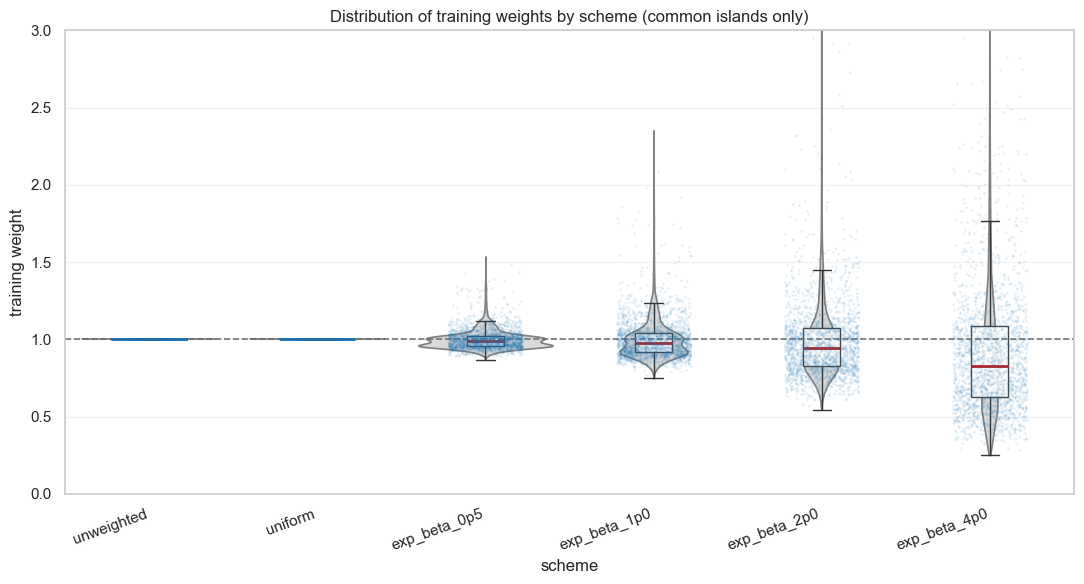

,weight_scheme,n,mean,median,std,min,max,q10,q90
5,unweighted,399800,1.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
4,uniform,79960,1.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
0,exp_beta_0p5,79960,1.0,0.990230,0.062158,0.867419,1.536542,0.940115,1.073824
1,exp_beta_1p0,79960,1.0,0.977593,0.132006,0.747406,2.353385,0.879237,1.147435
2,exp_beta_2p0,79960,1.0,0.942798,0.305906,0.543336,5.471189,0.755157,1.288832
3,exp_beta_4p0,79960,1.0,0.825925,0.943549,0.248548,29.319578,0.503411,1.494802


In [43]:
# Figure 5: Distribution of training weights by scheme

weighted_indiv_path = _find_csv(BPCRR_WEIGHT_DIR, "bpcrr_inla_weighted_individuals.csv")
if weighted_indiv_path is None:
    raise FileNotFoundError("Could not find bpcrr_inla_weighted_individuals.csv under BPCRR_WEIGHT_DIR")

weighted_indiv = pd.read_csv(weighted_indiv_path)
required_cols = {"weight_scheme", "weight", "target_island"}
missing_cols = required_cols.difference(weighted_indiv.columns)
if missing_cols:
    raise ValueError(f"weighted_indiv is missing required columns: {sorted(missing_cols)}")

# Keep only the beta schemes plus uniform.
scheme_mask = (
    weighted_indiv["weight_scheme"].astype(str).eq("uniform")
    | weighted_indiv["weight_scheme"].astype(str).str.startswith("exp_beta_")
)
dist_df = weighted_indiv[scheme_mask].copy()
if dist_df.empty:
    raise ValueError("No uniform/exp_beta schemes found in weighted individuals file")

# Keep the same island scope as earlier figures.
dist_df = dist_df[dist_df["target_island"].isin(target_islands_to_plot)].copy()

# Fair comparison: only islands present for all weighted schemes.
weighted_wide = dist_df.groupby(["target_island", "weight_scheme"], as_index=False)["weight"].size()
presence = weighted_wide.pivot(index="target_island", columns="weight_scheme", values="size")
common_islands = presence.dropna().index.tolist()
if not common_islands:
    raise ValueError("No common target islands across weighted schemes")
dist_df = dist_df[dist_df["target_island"].isin(common_islands)].copy()

# Add explicit unweighted reference with constant weight 1.0 on the same rows.
unweighted_df = dist_df.copy()
unweighted_df["weight_scheme"] = "unweighted"
unweighted_df["weight"] = 1.0

dist_plot = pd.concat([dist_df, unweighted_df], ignore_index=True)

def _beta_sort_key(scheme: str):
    s = str(scheme)
    if s == "unweighted":
        return (-2.0, s)
    if s == "uniform":
        return (-1.0, s)
    if s.startswith("exp_beta_"):
        val = s.replace("exp_beta_", "").replace("p", ".")
        try:
            return (float(val), s)
        except ValueError:
            return (999.0, s)
    return (999.0, s)

scheme_order = sorted(dist_plot["weight_scheme"].unique().tolist(), key=_beta_sort_key)

# Optional light downsampling for points to keep plotting responsive.
max_points = 20000
if len(dist_plot) > max_points:
    strip_df = dist_plot.sample(n=max_points, random_state=42)
else:
    strip_df = dist_plot

print("Schemes:", scheme_order)
print("Common islands across weighted schemes:", len(common_islands))
print("Rows in distribution plot:", len(dist_plot))

plt.figure(figsize=(11, 6))
sns.violinplot(
    data=dist_plot,
    x="weight_scheme",
    y="weight",
    order=scheme_order,
    inner=None,
    cut=0,
    color="#d9d9d9",
)
sns.boxplot(
    data=dist_plot,
    x="weight_scheme",
    y="weight",
    order=scheme_order,
    width=0.22,
    showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": "#333333", "alpha": 0.9},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    medianprops={"color": "#b22222", "linewidth": 2},
)
sns.stripplot(
    data=strip_df,
    x="weight_scheme",
    y="weight",
    order=scheme_order,
    color="#1f77b4",
    size=1.8,
    alpha=0.12,
    jitter=0.22,
    linewidth=0,
)

plt.axhline(1.0, color="#666666", linestyle="--", linewidth=1.2, alpha=0.9)
plt.title("Distribution of training weights by scheme (common islands only)")
plt.xlabel("scheme")
plt.ylabel("training weight")
plt.xticks(rotation=20, ha="right")
plt.ylim(top=3, bottom=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

summary_dist = (
    dist_plot.groupby("weight_scheme")["weight"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        q10=lambda s: s.quantile(0.10),
        q90=lambda s: s.quantile(0.90),
    )
    .reset_index()
    .sort_values("weight_scheme", key=lambda s: s.map({k: i for i, k in enumerate(scheme_order)}))
)
display(summary_dist)